In [1]:
!apt-get update

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [4,420 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,200 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/un

In [2]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

In [4]:
!wget -q https://archive.apache.org/dist/spark/spark-3.3.2/spark-3.3.2-bin-hadoop3.tgz

In [5]:
!tar -xvf spark-3.3.2-bin-hadoop3.tgz

spark-3.3.2-bin-hadoop3/
spark-3.3.2-bin-hadoop3/LICENSE
spark-3.3.2-bin-hadoop3/NOTICE
spark-3.3.2-bin-hadoop3/R/
spark-3.3.2-bin-hadoop3/R/lib/
spark-3.3.2-bin-hadoop3/R/lib/SparkR/
spark-3.3.2-bin-hadoop3/R/lib/SparkR/DESCRIPTION
spark-3.3.2-bin-hadoop3/R/lib/SparkR/INDEX
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/Rd.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/features.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/hsearch.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/links.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/nsInfo.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/package.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/Meta/vignette.rds
spark-3.3.2-bin-hadoop3/R/lib/SparkR/NAMESPACE
spark-3.3.2-bin-hadoop3/R/lib/SparkR/R/
spark-3.3.2-bin-hadoop3/R/lib/SparkR/R/SparkR
spark-3.3.2-bin-hadoop3/R/lib/SparkR/R/SparkR.rdb
spark-3.3.2-bin-hadoop3/R/lib/SparkR/R/SparkR.rdx
spark-3.3.2-bin-hadoop3/R/lib/SparkR/doc/
spark-3.3.2-bin-hadoop3/R/lib/Spar

In [6]:
!pip install -q findspark

In [7]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.3.2-bin-hadoop3"

In [8]:
import findspark
findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").getOrCreate()

In [9]:
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

--2025-05-02 08:50:30--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.002s  

2025-05-02 08:50:30 (30.7 MB/s) - ‘titanic.csv’ saved [60302/60302]



In [10]:
df=spark.read.csv('titanic.csv',inferSchema=True, header=True)

In [12]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Создание Spark-сессии
spark = SparkSession.builder \
    .appName("Titanic Regression with PySpark") \
    .getOrCreate()

# Загрузка датасета
df = spark.read.csv("titanic.csv", header=True, inferSchema=True)

# Отбираем числовые и категориальные фичи
df = df.select("Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare")

# Удалим строки с пропущенными значениями
df = df.dropna()

# Индексируем категориальный признак "Sex"
indexer = StringIndexer(inputCol="Sex", outputCol="SexIndexed")
df = indexer.fit(df).transform(df)

# Собираем вектор признаков
assembler = VectorAssembler(
    inputCols=["Pclass", "SexIndexed", "Age", "SibSp", "Parch", "Fare"],
    outputCol="features"
)
df = assembler.transform(df).select("features", "Survived")

# Разделение на train и test
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

# Линейная регрессия
lr = LinearRegression(featuresCol="features", labelCol="Survived")
lr_model = lr.fit(train_data)

# Предсказание
predictions = lr_model.transform(test_data)

# Оценка качества — метрика MSE
evaluator = RegressionEvaluator(labelCol="Survived", predictionCol="prediction", metricName="mse")
mse = evaluator.evaluate(predictions)
print(f"📉 MSE модели линейной регрессии: {mse:.4f}")


📉 MSE модели линейной регрессии: 0.1451


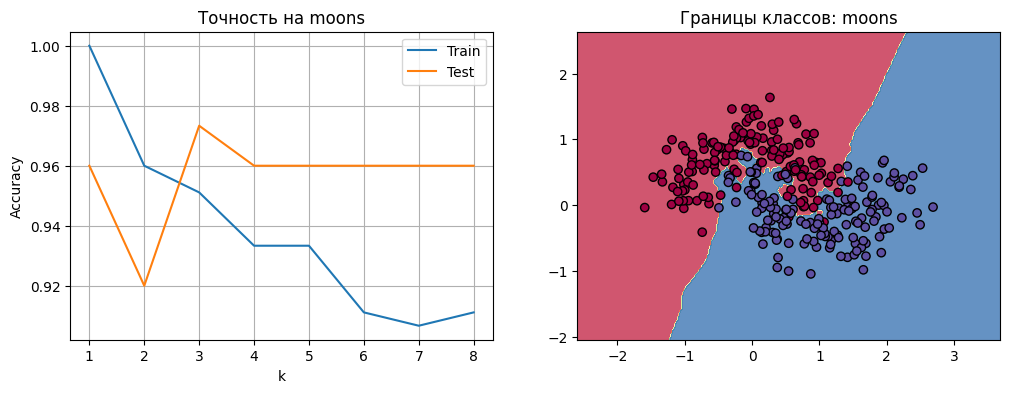

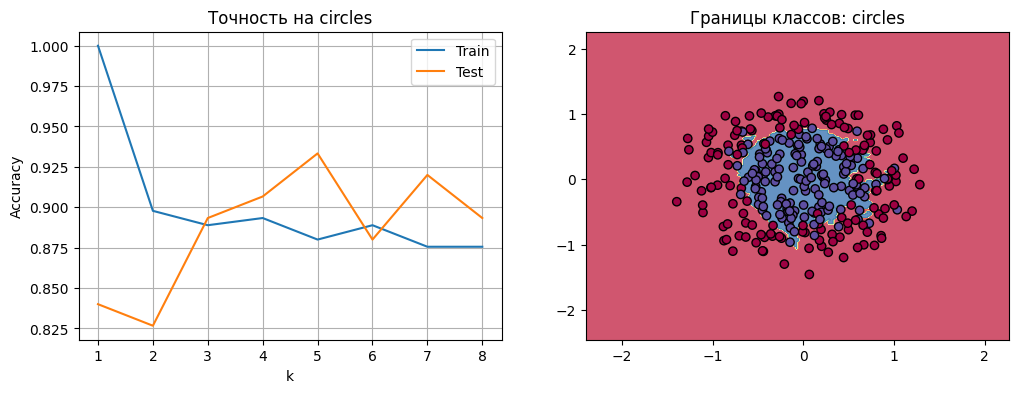

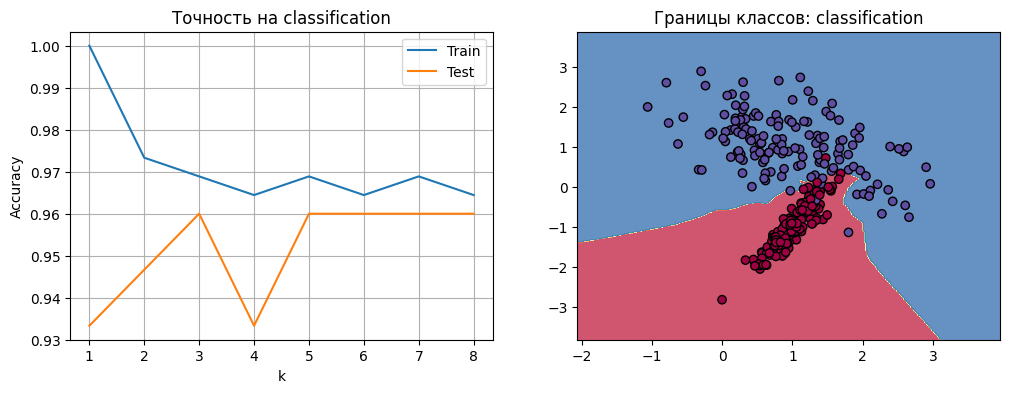

In [21]:
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

datasets = {
    "moons": make_moons(n_samples=300, noise=0.25, random_state=42),
    "circles": make_circles(n_samples=300, noise=0.2, factor=0.5, random_state=42),
    "classification": make_classification(n_samples=300, n_features=2, n_informative=2,
                                           n_redundant=0, n_clusters_per_class=1, random_state=42)
}

for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

    train_accuracies = []
    test_accuracies = []

    for k in range(1, 9):
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_train, y_train)
        train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
        test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, 9), train_accuracies, label="Train")
    plt.plot(range(1, 9), test_accuracies, label="Test")
    plt.xlabel("k")
    plt.ylabel("Accuracy")
    plt.title(f"Точность на {name}")
    plt.legend()
    plt.grid(True)

    clf_best = KNeighborsClassifier(n_neighbors=3)
    clf_best.fit(X_train, y_train)

    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf_best.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(1, 2, 2)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, edgecolors='k')
    plt.title(f"Границы классов: {name}")
    plt.show()


In [18]:
import numpy as np
from collections import Counter

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def predict(self, X_test):
        X_test = np.array(X_test)

        # Вычисляем евклидово расстояние от всех точек X_test до всех X_train
        # (broadcasting + векторизация)
        dists = np.sqrt(
            ((X_test[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]) ** 2).sum(axis=2)
        )

        # Получаем индексы k ближайших соседей
        k_indices = np.argsort(dists, axis=1)[:, :self.k]

        # Получаем соответствующие метки
        k_neighbor_labels = self.y_train[k_indices]

        # Выбираем наиболее частую метку по строкам
        y_pred = np.array([Counter(row).most_common(1)[0][0] for row in k_neighbor_labels])
        return y_pred


In [19]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Генерация данных
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучение KNN
knn = KNNClassifier(k=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Оценка качества
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy на test: {acc:.4f}")


🎯 Accuracy на test: 0.9000
